In [2]:
# import os
# from utils_ipynb import get_local_folder
# notebook_dir = get_local_folder()
# os.chdir(f"{notebook_dir}/..")
import os
import json
import matplotlib.pyplot as plt
os.chdir(f"/home/zx/nas/GitRepos/kma")


## MisInfo

In [3]:
edit_result_json = "./simulate_attack_defense/ft_plus_with_diff_rephrase_data_misinfo.json"

from utils import init_plot
import json

data = json.load(open(edit_result_json, "r"))

total_splits = len(data)
print("Total Data Split: ", total_splits)


Total Data Split:  100


[24, 51, 53, 88, 54, 5, 50, 18, 26, 42, 43, 95, 32, 66, 99, 86, 90, 30, 40, 49, 82, 1, 80, 71, 22, 60, 62, 64, 28, 39, 8, 91, 83, 84, 67, 72, 58, 31, 33, 55, 44, 45, 89, 10, 11, 12, 15, 13, 94, 96, 98, 27, 20, 57, 52, 61, 65, 69, 7, 78, 76, 75, 74, 38, 9, 37, 92, 2, 17, 0, 36, 68, 79, 34, 25, 19, 14, 16, 87, 85, 56, 23, 93, 47, 77, 73, 35, 46, 4, 97, 6, 29, 63, 21, 41, 59, 70, 3, 48, 81]
Data Split Idx: 24, Steps: 21, loss_after_attack: 0.2288818359375, loss_after_agg: 5.82421875, post_edit_acc:1.0
Data Split Idx: 51, Steps: 21, loss_after_attack: 0.826171875, loss_after_agg: 5.765625, post_edit_acc:1.0
Data Split Idx: 53, Steps: 21, loss_after_attack: 0.11383056640625, loss_after_agg: 5.90234375, post_edit_acc:1.0
Data Split Idx: 88, Steps: 22, loss_after_attack: 0.2220458984375, loss_after_agg: 5.97265625, post_edit_acc:1.0
Data Split Idx: 54, Steps: 22, loss_after_attack: 0.1185302734375, loss_after_agg: 5.921875, post_edit_acc:1.0
Data Split Idx: 5, Steps: 24, loss_after_attack: 0.

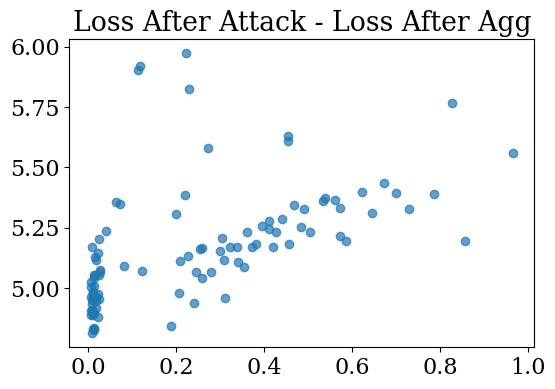

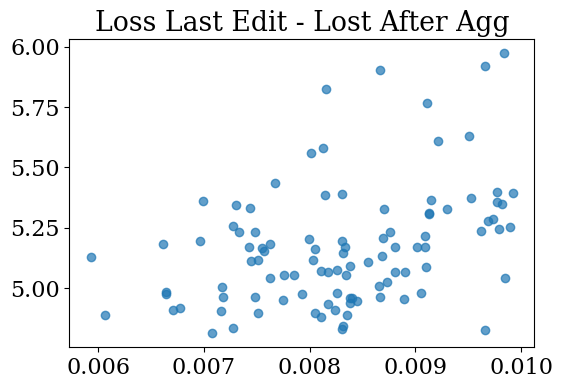

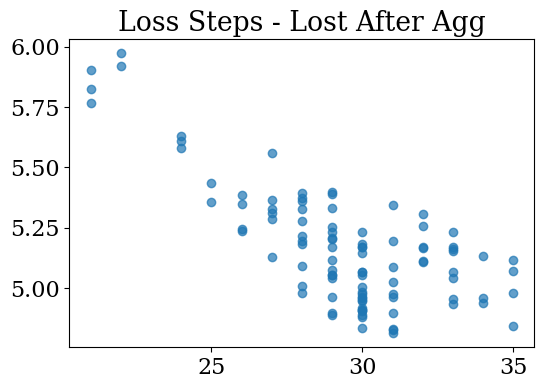

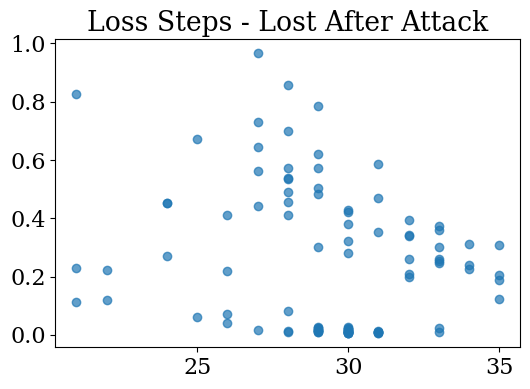

In [4]:
total_splits = len(data)

### loss after agg与loss after attack关系
loss_after_agg, loss_after_attack = [], []
edit_loss_history = [] 
post_edit_acc = []

for d in data:
    loss_after_agg.append(d["loss_after_agg"])
    loss_after_attack.append(d["loss_after_attack"])
    edit_loss_history.append(d["loss_history"][0])
    post_edit_acc.append(d["edit_metric"][0]["post"]["rewrite_acc"][0])

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(loss_after_attack, loss_after_agg, alpha=0.7)
ax.set_title("Loss After Attack - Loss After Agg")

# ### attack loss 最终值 与loss after agg关系
edit_loss_last_step = [ loss[-1] for loss in edit_loss_history]

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]


ax.scatter(edit_loss_last_step, loss_after_agg, alpha=0.7)
ax.set_title("Loss Last Edit - Lost After Agg")

# ### attack loss 步数 与loss after agg关系

edit_loss_total_steps = [ len(loss) for loss in edit_loss_history]


fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(edit_loss_total_steps, loss_after_agg, alpha=0.7)
ax.set_title("Loss Steps - Lost After Agg")

# ### attack loss 步数 与loss after attack关系

edit_loss_total_steps = [ len(loss) for loss in edit_loss_history]


fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(edit_loss_total_steps, loss_after_attack, alpha=0.7)
ax.set_title("Loss Steps - Lost After Attack")

## 打印loss steps 最少的data split
import numpy as np
sorted_indices = np.argsort(np.array(edit_loss_total_steps)).tolist()
print(sorted_indices)

for i in sorted_indices[:10]:
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}, post_edit_acc:{post_edit_acc[i]}")


In [ ]:

split_data_val = {
    68: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.04, 0.04, 0.04, 0.06, 0.28],
    41: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.16, 0.14, 0.14, 0.16, 0.22],
    94: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.28, 0.24, 0.34, 0.3, 0.86], 
    62: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.02, 0.0, 0.24, 0.26, 0.24, 0.22, 0.26, 0.5, 0.54, 0.5, 0.56, 0.86], 
    45: [0.0, 0.0, 0.04, 0.0, 0.0, 0.0, 0.0, 0.16, 0.04, 0.1, 0.36, 0.52, 0.42, 0.3, 0.34, 0.74, 0.8, 0.8, 0.76, 0.94], 
    88: [0.0, 0.0, 0.1, 0.04, 0.0, 0.0, 0.0, 0.28, 0.06, 0.26, 0.56, 0.6, 0.62, 0.44, 0.5, 0.82, 0.88, 0.84, 0.86, 0.94],
    
    53: [0.0, 0.0, 0.06, 0.0, 0.0, 0.0, 0.0, 0.18, 0.1, 0.14, 0.46, 0.64, 0.58, 0.44, 0.44, 0.8, 0.84, 0.86, 0.86, 0.98],
    24: [0.0, 0.0, 0.04, 0.0, 0.0, 0.0, 0.0, 0.22, 0.02, 0.14, 0.52, 0.54, 0.56, 0.44, 0.44, 0.82, 0.86, 0.86, 0.86, 0.94],
    51: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08, 0.0, 0.0, 0.28, 0.3, 0.28, 0.2, 0.22, 0.52, 0.52, 0.5, 0.54, 0.76],
    54: [0.0, 0.0, 0.32, 0.08, 0.0, 0.0, 0.0, 0.52, 0.48, 0.54, 0.74, 0.7, 0.62, 0.62, 0.68, 0.9, 0.86, 0.88, 0.9, 0.96],
    
    "least_agg_rank": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.02, 0.02, 0.02, 0.16]
}


# Data Split Idx: 53, Steps: 21, loss_after_attack: 0.11383056640625, loss_after_agg: 5.90234375, post_edit_acc:1.0
# Data Split Idx: 24, Steps: 21, loss_after_attack: 0.2288818359375, loss_after_agg: 5.82421875, post_edit_acc:1.0
# Data Split Idx: 51, Steps: 21, loss_after_attack: 0.826171875, loss_after_agg: 5.765625, post_edit_acc:1.0
#
# Data Split Idx: 54, Steps: 22, loss_after_attack: 0.1185302734375, loss_after_agg: 5.921875, post_edit_acc:1.0
# Data Split Idx: 88, Steps: 22, loss_after_attack: 0.2220458984375, loss_after_agg: 5.97265625, post_edit_acc:1.0



## Bias

In [ ]:
edit_result_json = "./simulate_attack_defense/ft_plus_with_diff_rephrase_data_bias.json"

from utils import init_plot
import json

data = json.load(open(edit_result_json, "r"))

total_splits = len(data)
print("Total Data Split: ", total_splits)


In [ ]:
total_splits = len(data)

### loss after agg与loss after attack关系
loss_after_agg, loss_after_attack = [], []
edit_loss_history = [] 

for d in data:
    loss_after_agg.append(d["loss_after_agg"])
    loss_after_attack.append(d["loss_after_attack"])
    edit_loss_history.append(d["loss_history"][0])

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(loss_after_attack, loss_after_agg, alpha=0.7)
ax.set_title("Loss After Attack - Loss After Agg")

# ### attack loss 最终值 与loss after agg关系
edit_loss_last_step = [ loss[-1] for loss in edit_loss_history]

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]


ax.scatter(edit_loss_last_step, loss_after_agg, alpha=0.7)
ax.set_title("Loss Last Edit - Lost After Agg")

# ### attack loss 步数 与loss after agg关系

edit_loss_total_steps = [ len(loss) for loss in edit_loss_history]


fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(edit_loss_total_steps, loss_after_agg, alpha=0.7)
ax.set_title("Loss Steps - Lost After Agg")

# ### attack loss 步数 与loss after attack关系

edit_loss_total_steps = [ len(loss) for loss in edit_loss_history]


fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.scatter(edit_loss_total_steps, loss_after_attack, alpha=0.7)
ax.set_title("Loss Steps - Lost After Attack")

## 打印loss steps 最少的data split
import numpy as np
sorted_indices = np.argsort(np.array(edit_loss_total_steps)).tolist()
print(sorted_indices)

for i in sorted_indices[:10]:
    print(f"Data Split Idx: {i}, Steps: {edit_loss_total_steps[i]}, loss_after_attack: {loss_after_attack[i]}, loss_after_agg: {loss_after_agg[i]}")

